In [25]:
%%capture

%pip install numpy pandas matplotlib yfinance
%pip install --upgrade pip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from scipy.stats import norm

### Sampling with/without replacement

We will use the "sample" command in Pandas to illustrate different kinds of sampling. Sampling with replacement is useful when you have a small population and you want to ensure that each item has the same chance of being picked. On the other hand, sampling without replacement is more appropriate when you have a large population, and you want to ensure that you draw distinct items each time.

In [2]:
population_size = 20
population = pd.Series(range(1, population_size + 1))    # creates a Pandas Series with values from 1 to population_size

Now, we sample 10 elements, **with** replacement.

In [3]:
sample_with_replacement = population.sample(n=10, replace=True)
print("Sample with replacement:\n", sample_with_replacement)
print("\n")
sample_without_replacement = population.sample(n=10, replace=False)
print("Sample without replacement:\n", sample_without_replacement)


Sample with replacement:
 10    11
2      3
15    16
16    17
2      3
10    11
7      8
3      4
5      6
10    11
dtype: int64


Sample without replacement:
 3      4
8      9
10    11
6      7
16    17
4      5
15    16
1      2
17    18
18    19
dtype: int64


We can also distinguish between the statistics of the population and those of the sample.

In [4]:
population_mean = population.mean()
population_std = population.std(ddof=0)
print(f"Population mean = {population_mean}, Population std = {population_std}")

sample_mean = sample_with_replacement.mean()
sample_std = sample_with_replacement.std(ddof=1)
print(f"Sample mean = {sample_mean}, Sample std = {sample_std}")

Population mean = 10.5, Population std = 5.766281297335398
Sample mean = 9.0, Sample std = 5.0771820705759385


### Unbiased estimator

Note that the sample variance (and thus, the standard deviation) is calculated using 1 degree of freedom, since this makes it an unbiased estimator. This means that the average value (across many samples) of the sample variance is the same as the population variance. We now verify this.

In [5]:
data = pd.Series(np.random.randn(500))
samples = np.random.choice(data, size=(1000, 100), replace=True)    # creates an array of 1000 realizations of 100 samples each
sample_means = np.mean(samples, axis=1)
sample_vars_unbiased = np.var(samples, axis=1, ddof=1)
sample_vars_biased = np.var(samples, axis=1, ddof=0)

print('Population statistics:')
print(f"Mean = {data.mean()}, Variance = {data.var(ddof=0)}")
print('--------------------------------')
print('Sample statistics:')
print(f"Unbiased mean = {np.mean(sample_means)}, Unbiased variance = {np.mean(sample_vars_unbiased)}, Biased variance = {np.mean(sample_vars_biased)}")

Population statistics:
Mean = -0.01262063376725489, Variance = 1.0289866785744455
--------------------------------
Sample statistics:
Unbiased mean = -0.009610754623344694, Unbiased variance = 1.0268126027497182, Biased variance = 1.0165444767222211


Next, we will explore how the sample statistics behave as the number of realizations are increased.

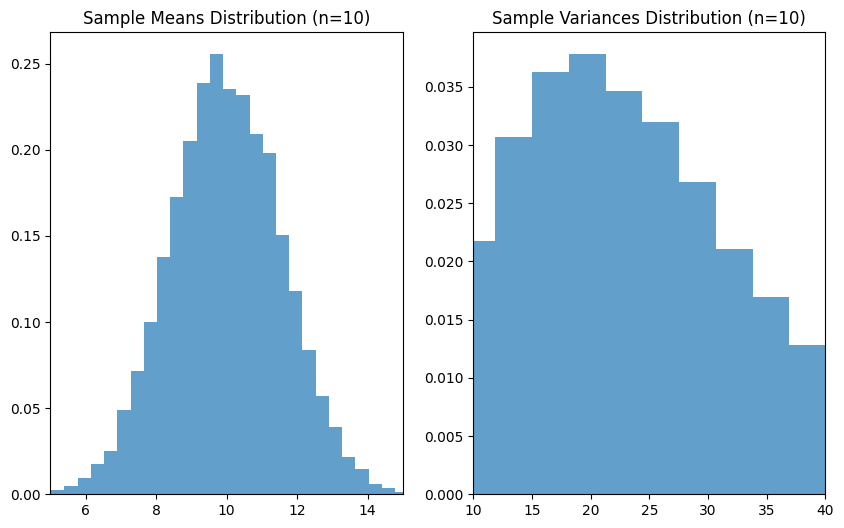

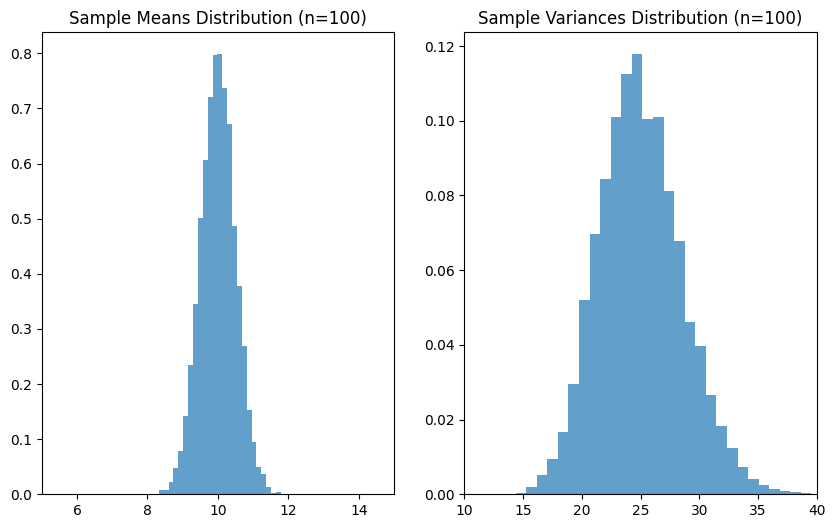

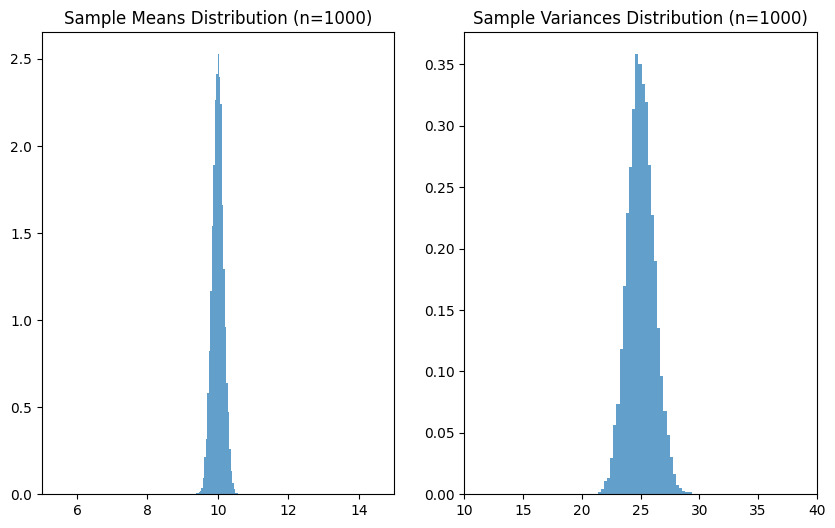

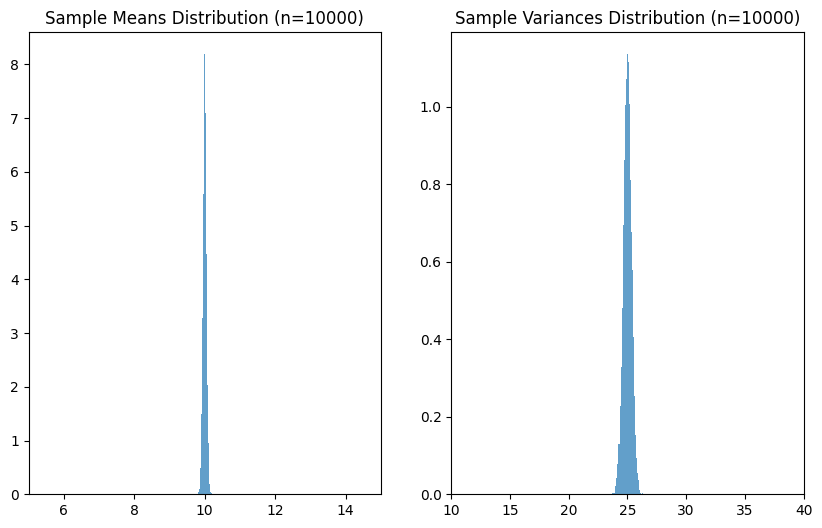

In [8]:
N = [10, 100, 1000, 10000]    # sample sizes to consider

for n in N:
    samples = np.random.normal(10,5, size=(10000, n))
    sample_means = np.mean(samples, axis=1)
    sample_vars = np.var(samples, axis=1, ddof=1)
    plt.figure(figsize=(10, 6))
    plt.subplot(1, 2, 1)
    plt.hist(sample_means, bins=30, density=True, alpha=0.7)
    plt.xlim(5, 15)
    plt.title(f'Sample Means Distribution (n={n})')
    plt.subplot(1, 2, 2)
    plt.hist(sample_vars, bins=30, density=True, alpha=0.7)
    plt.xlim(10, 40)
    plt.title(f'Sample Variances Distribution (n={n})')
    plt.show()

We observe that as the size of the samples increases, the sample statistics approach the population statistics. This is the central limit theorem (CLT). There is a difference in the method of approach, though. The histogram of the sample mean is a normal distribution that is increasingly sharper, i.e., the variance of the sample mean goes to $0$, and we end up with a Dirac delta distribution in the limit. The histogram of the variance is a $\chi^2$ distribution though. Indeed, $\frac{n-1}{\sigma^2} s^2 \sim \chi^2(n-1)$, where $s^2$ is the sample variance and $\sigma^2$ is the population variance. As $n\rightarrow\infty$, we have $s^2\rightarrow \sigma^2$ and $\text{Var}[s^2]\rightarrow 0$, since $\mathbb{E}[\chi^2(n-1)] = n-1$ and $\text{Var}[\chi^2(n-1)] = 2(n-1)$.

**Note**: Increasing the number of realizations only enhances the clarity of the distribution, but does not affect the actual behavior of the CLT.

### Confidence intervals around sample means

Given a sample of $n\gg 1$ points, suppose we calculate the mean $(\bar{x})$. We will denote the population mean and variance by $\mu$ and $\sigma^2$, respectively. Then, we know from the central limit theorem that
$$\frac{\bar{x} - \mu}{\frac{\sigma}{\sqrt{n}}} \sim N(0,1).$$

If we set a significance level of $\alpha$, then with confidence $1-\alpha$, we can say that
$$P\left(z_{\frac{\alpha}{2}} \le \frac{\bar{x} - \mu}{\frac{\sigma}{\sqrt{n}}} \le z_{1-\frac{\alpha}{2}}\right) = 1-\alpha,$$
where $z_{\beta}$ is the z-score corresponding to significance level of $\beta$. Since the standard normal distribution is symmetric, we know that $z_{1-\frac{\alpha}{2}} = -z_{\frac{\alpha}{2}}$. Therefore, we can rearrange the above equation to obtain
$$P\left(\bar{x} - \frac{\sigma}{\sqrt{n}}z_{\frac{\alpha}{2}} \le \mu \le \bar{x} + \frac{\sigma}{\sqrt{n}}z_{\frac{\alpha}{2}}\right) = 1-\alpha.$$

In other words, we are able to state, at a confidence level of $\alpha$, that the true mean lies within a certain window. 

**Note**: This argument assumes that $\sigma^2$ is already known. In practice, we just use the sample variance (unbiased). This is a good approximation as long as $n\gg 1$.

In [33]:
ticker_name = 'GOOGL'
stock_data = yf.download(ticker_name, start='2020-01-01', end='2025-12-31', group_by='Ticker')
stock_data = stock_data.dropna()
close_prices = stock_data[ticker_name]['Close']

log_returns = np.log(close_prices.shift(-1) / close_prices).dropna()
mean_log_return = log_returns.mean()
std_log_return = log_returns.std(ddof=1)
print(f"Mean log return = {mean_log_return}, Std log return = {std_log_return}")

confidence = 0.95
alpha = 1-confidence
z_score = norm.ppf(1 - alpha / 2)
n = log_returns.count()
ci_low = mean_log_return - z_score * std_log_return / np.sqrt(n)
ci_high = mean_log_return + z_score * std_log_return / np.sqrt(n)
print(f"95% Confidence Interval for mean log return: ({ci_low:.5f}, {ci_high:.5f})")

[*********************100%***********************]  1 of 1 completed

Mean log return = 0.0010163165878894315, Std log return = 0.02046031823617036
95% Confidence Interval for mean log return: (-0.00002, 0.00205)


### Hypothesis testing

This is a statistical approach to evaluating the validity of various assertions. We begin with two fundamental definitions:
- Null hypothesis ($H_0$): This is the assertion that we are *opposing*.
- Alternative hypothesis ($H_a$): This is the conclusion we *favor*, and we accept this whenever we reject the null hypothesis.

Suppose you are given a data set that is claimed to be the log-returns of an asset. You want to check if this data is real or if it has been fabricated, i.e., does the data follow the actual distribution of the asset's dynamics? Let the population mean be $\mu$, and let our sample mean be $\bar{x}$. Our null hypothesis is that the data is accurate. If we assume that this is correct, then we expect $\bar{x}$ to be close to $\mu$. How close? We have to take into account the spread of the population. To be more precise, we will look at the size of
$$\hat{z} = \frac{\bar{x}-\mu}{\frac{\sigma}{\sqrt{n}}},$$
where $\sigma$ is the standard deviation of the population and $n$ is the number of data points. We know from the CLT that $\hat{z}\sim N(0,1)$. In practice, we do not know the population variance $\sigma^2$, so we will replace it with the (unbiased) sample variance $s^2$, which leads to the quantity
$$\hat{t} = \frac{\bar{x}-\mu}{\frac{s}{\sqrt{n}}} = \frac{\left(\frac{\bar{x}-\mu}{\frac{\sigma}{\sqrt{n}}}\right)}{\sqrt{\frac{\left(\frac{(n-1)s^2}{\sigma^2}\right)}{n-1}}} = \frac{\hat{z}}{\sqrt{\frac{\hat{v}}{n-1}}}.$$
From earlier, we know that the variable $\hat{v} = \frac{(n-1)s^2}{\sigma^2}$ follows a $\chi^2$ distribution with $n-1$ degrees of freedom. The ratio of a standard normal variable to the square-root of a $\chi^2$ variable (normalized by its degrees of freedom) is a random variable that is governed by **Student's t-distribution**. This distribution is also a bell-shaped curve symmetric about $x=0$, but it has fatter tails than the standard normal distribution. 

*Note*: As $n\rightarrow\infty$, we note that $\hat{t} \rightarrow \hat{z}$, i.e., the t-distribution becomes indistinguishable from the standard normal distribution.

### An example

Suppose we wish to test the hypothesis that the mean log-return of an asset is positive, i.e., the asset is going to increase. The assertion is that there is indeed a positive drift of the asset value over time, and it is not purely a result of random fluctuations.

Our null hypothesis is that $\mu\le 0$. The alternative hypothesis is that $\mu>0$. Under the assumption of the null hypothesis, we will use the sample statistics to set up $\hat{t} = \frac{\bar{x} - \mu}{\frac{s}{\sqrt{n}}} \ge \frac{\bar{x}}{\frac{s}{\sqrt{n}}}$. Then, we use the t-distribution to evaluate the probability $P(t>\hat{t}) \ge P\left( t > \frac{\bar{x}}{\frac{s}{\sqrt{n}}}\right) = p$. This **p-value** tells us the probability of observing a mean log-return that is at least as large as $\bar{x}$, under the null hypothesis. If this is above a certain significance threshold (commonly, $\alpha=0.05$), then we *fail to reject* the null hypothesis. Otherwise, we reject it and choose the alternative hypothesis instead. 

Let us numerically evaluate this.

In [38]:
ticker_name = 'GOOGL'
stock_data = yf.download(ticker_name, start='2020-01-01', end='2025-12-31')
stock_data.columns = stock_data.columns.droplevel('Ticker')
log_returns = np.log(stock_data['Close'].shift(-1) / stock_data['Close']).dropna()

mean_log_return = log_returns.mean()
std_log_return = log_returns.std(ddof=1)
n = log_returns.count()
t_stat = mean_log_return / (std_log_return / np.sqrt(n))

from scipy.stats import t
confidence = 0.95
alpha = 1 - confidence
p = t.sf(t_stat, df=n-1)

print(f"t-statistic = {t_stat:.5f}, p-value = {p:.5e}")
if p < alpha:
    print(f"Reject the null hypothesis. (Strong evidence of positive drift.)")
else:
    print(f"Fail to reject the null hypothesis. (Insufficient evidence of positive drift.)")


# We can also use the built-in function from SciPy to perform the one-sample t-test for verification
from scipy.stats import ttest_1samp
res = ttest_1samp(log_returns, popmean=0, alternative='greater')
print(f"\n SciPy Verification -> t-stat: {res.statistic:.5f}, p-value: {res.pvalue:.5e}")


[*********************100%***********************]  1 of 1 completed

t-statistic = 1.92765, p-value = 2.70431e-02
Reject the null hypothesis. (Strong evidence of positive drift.)

 SciPy Verification -> t-stat: 1.92765, p-value: 2.70431e-02


We can also modify the above example to check the assertion that the drift is *non-zero*. In this case, our null hypothesis would be that $\mu = 0$. Under the null hypothesis, the t-statistic is $\hat{t} = \frac{\bar{x}}{\frac{s}{\sqrt{n}}}$. Now, we will look for the probability $p = P(t>|\hat{t}|) + P(t< -|\hat{t}|) = 2P(t>|\hat{t}|)$. This is called a **two-tailed test**, in contrast to the one-tailed test from above. This p-value tells us the probability of observing a sample mean that deviates from 0 by at least as much as $\hat{x}$ in *either* direction, assuming the null hypothesis is true.

This can also be evaluated from scratch, using the survival function of the t-distribution. Or, we could use the built-in SciPy function.

In [40]:
from scipy.stats import ttest_1samp
res = ttest_1samp(log_returns, popmean=0)
print(f"\n SciPy Verification -> t-stat: {res.statistic:.5f}, p-value: {res.pvalue:.5e}")

if p < alpha:
    print(f"Reject the null hypothesis. (Strong evidence of non-zero drift.)")
else:
    print(f"Fail to reject the null hypothesis. (Insufficient evidence of non-zero drift.)")


 SciPy Verification -> t-stat: 1.92765, p-value: 5.40862e-02
Reject the null hypothesis. (Strong evidence of non-zero drift.)
